In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


All Datasets have the same row name: Same genes

In [ ]:
filenames = ['GSM5494348_SCG-PCA21-T-LG.count.csv', 'GSM5494350_SCG-PCA3-T-LG.count.csv', 'GSM5494352_SCG-PCA4-T-HG.count.csv', 'GSM5494354_SCG-PCA5-T-LG.count.csv',
      'GSM5494356_SCG-PCA6-T-HG.count.csv', 'GSM5494358_SCG-PCA7-T-HG.count.csv', 'GSM5494359_SCG-PCA8-T-HG.count.csv', 'GSM5494360_SCG-PCA9-T-LG.count.csv',
      'GSM5494362_SCG-PCA10-T-LG.count.csv', 'GSM5494363_SCG-PCA11-T-LG.count.csv', 'GSM5494365_SCG-PCA12-T-LG.count.csv', 'GSM5494368_SCG-PCA15-T-HG.count.csv',
      'GSM5494369_SCG-PCA16-T-HG.count.csv', 'GSM5494371_SCG-PCA17-T-LG.count.csv', 'GSM5494373_SCG-PCA18-T-LG.count.csv', 'GSM5494375_SCG-PCA19-T-HG.count.csv',
      'GSM5494377_SCG-PCA20-T-LG.count.csv', 'GSM5494379_SCG-PCA22-T-HG.count.csv']

first_column_contents = None
consistent = True

for name in filenames:
    file_path = "/content/drive/MyDrive/New_Dataset/" + name
    gene_expression = pd.read_csv(file_path)

    current_column = set(gene_expression.iloc[:, 0])

    if first_column_contents is None:
        first_column_contents = current_column
    else:
        if current_column != first_column_contents:
            consistent = False
            print(f"Inconsistent first column in file: {name}")
            break

if consistent:
    print("All files have the same contents in the first column.")
else:
    print("The files do not have consistent contents in the first column.")

All files have the same contents in the first column.


Tidy Up Gene Expression Datasets

In [ ]:
filenames = ['GSM5494352_SCG-PCA4-T-HG.count.csv', 'GSM5494356_SCG-PCA6-T-HG.count.csv', 'GSM5494358_SCG-PCA7-T-HG.count.csv', 'GSM5494359_SCG-PCA8-T-HG.count.csv',
       'GSM5494368_SCG-PCA15-T-HG.count.csv', 'GSM5494369_SCG-PCA16-T-HG.count.csv', 'GSM5494375_SCG-PCA19-T-HG.count.csv', 'GSM5494379_SCG-PCA22-T-HG.count.csv']

combined_df = pd.concat(
    [pd.read_csv(f"/content/drive/MyDrive/New_Dataset/{file}", index_col=0) for file in filenames],
    axis=1
)

print(combined_df.shape)

(32725, 28990)


In [ ]:
combined_df.head()

,SCG-PCA4-T-HG_AAACCTGAGCCACGTC-1,SCG-PCA4-T-HG_AAACCTGAGGCGTACA-1,SCG-PCA4-T-HG_AAACCTGAGTGACATA-1,SCG-PCA4-T-HG_AAACCTGAGTTGTAGA-1,SCG-PCA4-T-HG_AAACCTGCAAGCCGCT-1,SCG-PCA4-T-HG_AAACCTGCATGCCTTC-1,SCG-PCA4-T-HG_AAACCTGGTAAGAGGA-1,SCG-PCA4-T-HG_AAACCTGGTCATATGC-1,SCG-PCA4-T-HG_AAACCTGGTTACCGAT-1,SCG-PCA4-T-HG_AAACCTGTCCGTCATC-1,...,SCG-PCA22-T-HG_TTTGTCACATTAGGCT-1,SCG-PCA22-T-HG_TTTGTCACATTCGACA-1,SCG-PCA22-T-HG_TTTGTCAGTAAGGGCT-1,SCG-PCA22-T-HG_TTTGTCAGTAGGGACT-1,SCG-PCA22-T-HG_TTTGTCAGTCTAGGTT-1,SCG-PCA22-T-HG_TTTGTCAGTGGGTCAA-1,SCG-PCA22-T-HG_TTTGTCAGTGGTTTCA-1,SCG-PCA22-T-HG_TTTGTCAGTTAAAGAC-1,SCG-PCA22-T-HG_TTTGTCAGTTTAGCTG-1,SCG-PCA22-T-HG_TTTGTCATCATTTGGG-1
MIR1302-10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RP11-34P13.7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RP11-34P13.8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
gene_expression_t = combined_df.transpose()
print("\nShape of the data:", gene_expression_t.shape)
print("\nColumn names:", gene_expression_t.columns.tolist()[:10])

columns = gene_expression_t.columns
print(len(columns.unique()))


Shape of the data: (28990, 32725)

Column names: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2', 'RP4-669L17.10']
32725


In [ ]:
gene_expression_t.head()

,MIR1302-10,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,AL627309.1,RP11-34P13.14,RP11-34P13.9,AP006222.2,RP4-669L17.10,...,KIR3DL2.1,AL590523.1,CT476828.1,PNRC2.1,SRSF10.1,AC145205.1,BAGE5,CU459201.1,AC002321.2,AC002321.1
SCG-PCA4-T-HG_AAACCTGAGCCACGTC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCG-PCA4-T-HG_AAACCTGAGGCGTACA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCG-PCA4-T-HG_AAACCTGAGTGACATA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCG-PCA4-T-HG_AAACCTGAGTTGTAGA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCG-PCA4-T-HG_AAACCTGCAAGCCGCT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
def read_cell_types(file_path):
    cell_types = pd.read_csv(file_path)

    cell_types = pd.read_csv(file_path, header=None, skiprows=1, index_col=0)
    cell_types.columns = ['cells', 'sample']
    return cell_types

cell_type_file = "/content/drive/MyDrive/New_Dataset/GSE181294_scRNAseq.ano.csv"
cell_type = read_cell_types(cell_type_file)

print("\nFirst few rows of cell types data:")
print(cell_type.head())

print("\nShape of the data:", cell_type.shape)
print("\nUnique cell types:", cell_type['cells'].unique())


First few rows of cell types data:
                                        cells          sample
0                                                            
SCG-PCA21-N-LG_AAAGTAGTCAGAGCTT-1  Mast cells  SCG-PCA21-N-LG
SCG-PCA21-N-LG_AACTCAGGTAGTACCT-1  Mast cells  SCG-PCA21-N-LG
SCG-PCA21-N-LG_AACTTTCCAATTCCTT-1  Mast cells  SCG-PCA21-N-LG
SCG-PCA21-N-LG_AAGACCTTCGACCAGC-1  Mast cells  SCG-PCA21-N-LG
SCG-PCA21-N-LG_AAGGAGCCACTTGGAT-1  Mast cells  SCG-PCA21-N-LG

Shape of the data: (165159, 2)

Unique cell types: ['Mast cells' 'B cells' 'PDC' 'plasma cells' 'Epitheial_Club'
 'Epitheial_Hillock' 'Epitheial_Basal' 'Macrophage3' 'Macrophage1' 'Mono2'
 'Macrophage2' 'mDC' 'Mono3' 'Mono1' 'NK' 'TNK' 'CTL-1' 'CTL-2'
 'Cycling T' 'Naive Th' 'Th17' 'Th1' 'Treg' 'Pericytes-1'
 'Endothelial cells-1' 'Fibroblasts' 'Pericytes-2' 'Endothelial cells-2'
 'Epitheial_Luminal' 'Tumor' 'CD8+ effector']


In [ ]:
merged_data = pd.merge(cell_type, gene_expression_t, left_index=True, right_index=True, how='inner')
merged_data = merged_data.drop(columns=['sample'])

print(merged_data.shape)
print(merged_data.head())

(28855, 32726)
                                       cells  MIR1302-10  FAM138A  OR4F5  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1  Mast cells           0        0      0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1  Mast cells           0        0      0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1  Mast cells           0        0      0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1  Mast cells           0        0      0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1  Mast cells           0        0      0   

                                  RP11-34P13.7  RP11-34P13.8  AL627309.1  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1             0             0           0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1             0             0           0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1             0             0           0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1             0             0           0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1             0             0           0   

                                  RP11-34P13.14  RP11-34P13.9  AP006222

Data Cleansing

In [ ]:
non_zero_mask = (merged_data.iloc[:, 1:] != 0).any(axis=0)

cleansed_data = pd.concat(
    [merged_data['cells'], merged_data.iloc[:, 1:].loc[:, non_zero_mask]],
    axis=1
)

cleansed_data = cleansed_data.loc[:, ~cleansed_data.columns.duplicated()]

print(cleansed_data.shape)
print(cleansed_data.head())

(28855, 25565)
                                       cells  RP11-34P13.7  AL627309.1  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1  Mast cells             0           0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1  Mast cells             0           0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1  Mast cells             0           0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1  Mast cells             0           0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1  Mast cells             0           0   

                                  AP006222.2  RP4-669L17.10  RP5-857K21.3  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1           0              0             0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1           0              0             0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1           0              0             0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1           0              0             0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1           0              0             0   

                                  RP5-857K21.4  RP11-206L10.3  RP11-206L10.5 

In [ ]:
cleansed_data.to_csv("cleansed_dataset_new.csv", index=True)

In [ ]:
cleansed_data = pd.read_csv("/content/drive/MyDrive/New_Dataset/cleansed_dataset_new.csv", index_col=0)

cleansed_data.shape

(28855, 25565)

In [ ]:
genes_data = cleansed_data.iloc[:, 1:]

genes_data = genes_data.apply(pd.to_numeric, errors='coerce')
genes_data = genes_data.fillna(0)

column_sums = genes_data.sum(axis=0)

genes_tpm = genes_data.div(column_sums, axis=1) * 1e6

genes_log_tpm = np.log1p(genes_tpm)

global_min = genes_log_tpm.min().min()
global_max = genes_log_tpm.max().max()
genes_scaled = (genes_log_tpm - global_min) / (global_max - global_min)

normalized_data = pd.concat([cleansed_data[['cells']], genes_scaled], axis=1)

print("Shape of the normalized dataset:", normalized_data.shape)
print(normalized_data.head())

Shape of the normalized dataset: (28855, 25565)
                                       cells  RP11-34P13.7  AL627309.1  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1  Mast cells           0.0         0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1  Mast cells           0.0         0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1  Mast cells           0.0         0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1  Mast cells           0.0         0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1  Mast cells           0.0         0.0   

                                  AP006222.2  RP4-669L17.10  RP5-857K21.3  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1         0.0            0.0           0.0   

                                  RP5-857K21

In [ ]:
cell_types_column = normalized_data['cells'].str.strip().str.lower()

cell_type_mapping = {
    'Mast cells': 'Others',
    'B cells': 'B-cells',
    'PDC': 'DC',
    'plasma cells': 'B-cells',
    'Macrophage3': 'Macrophages',
    'Macrophage1': 'Macrophages',
    'Macrophage2': 'Macrophages',
    'Mono1': 'Monocytes',
    'Mono2': 'Monocytes',
    'Mono3': 'Monocytes',
    'mDC': 'DC',
    'NK': 'NK cells',
    'TNK': 'CD8+ T-cells',
    'CTL-1': 'CD8+ T-cells',
    'CTL-2': 'CD8+ T-cells',
    'Cycling T': 'CD4+ T-cells',
    'Naive Th': 'CD4+ T-cells',
    'Th17': 'CD4+ T-cells',
    'Th1': 'CD4+ T-cells',
    'Treg': 'CD4+ T-cells',
    'CD8+ effector': 'CD8+ T-cells',
    'Epitheial_Club': 'Epithelial cells',
    'Epitheial_Hillock': 'Epithelial cells',
    'Epitheial_Basal': 'Epithelial cells',
    'Epitheial_Luminal': 'Epithelial cells',
    'Tumor': 'Others',
    'Pericytes-1': 'Others',
    'Pericytes-2': 'Others',
    'Endothelial cells-1': 'Endothelial cells',
    'Endothelial cells-2': 'Endothelial cells',
    'Fibroblasts': 'Fibroblasts'
}

cell_type_mapping = {key.lower(): value for key, value in cell_type_mapping.items()}

normalized_data['cells'] = cell_types_column.map(cell_type_mapping)

print(normalized_data.head())

                                   cells  RP11-34P13.7  AL627309.1  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1  Others           0.0         0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1  Others           0.0         0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1  Others           0.0         0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1  Others           0.0         0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1  Others           0.0         0.0   

                                  AP006222.2  RP4-669L17.10  RP5-857K21.3  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1         0.0            0.0           0.0   

                                  RP5-857K21.4  RP11-206L10.3  RP11-206L10.5  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1    

In [ ]:
normalized_data.to_csv("normalized_dataset_new.csv", index=True)

Data Analysis

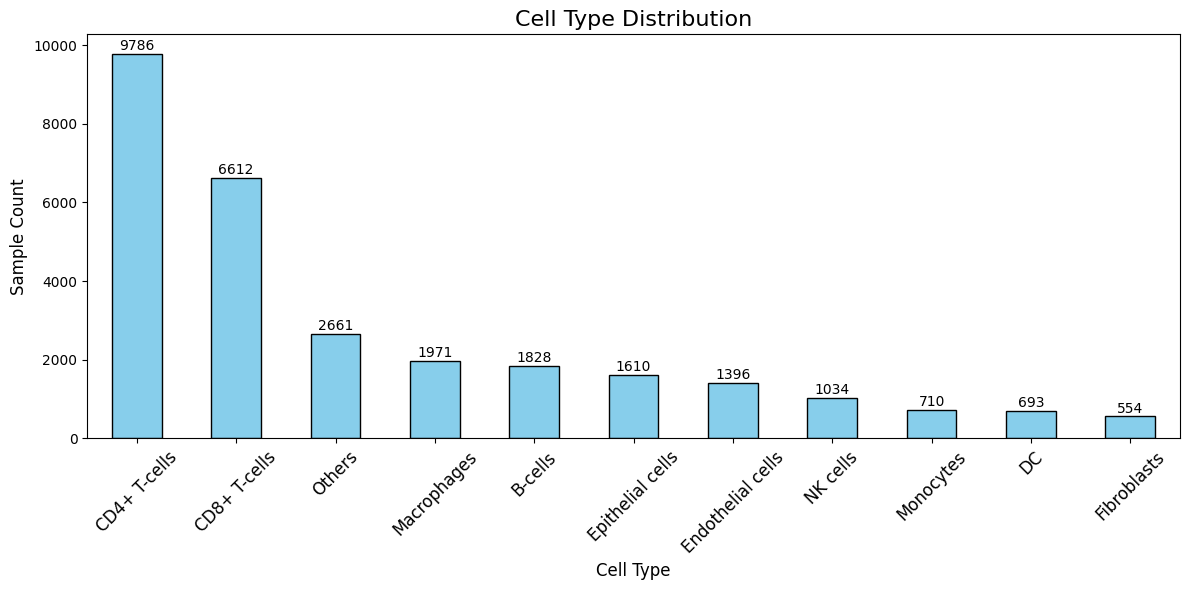

In [ ]:
cell_type_counts = normalized_data['cells'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = cell_type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cell Type Distribution', fontsize=16)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Sample Count', fontsize=12)
for i, count in enumerate(cell_type_counts):
    ax.text(i, count + 100, str(count), ha='center', fontsize=10)
plt.xticks(rotation=45, fontsize=12, ha='center')
plt.tight_layout()
plt.show()


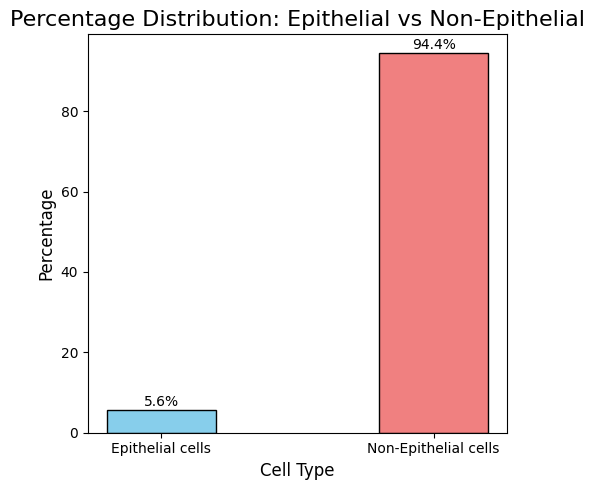

In [ ]:
epithelial_count = normalized_data['cells'].str.contains('Epithelial cells').sum()
non_epithelial_count = len(normalized_data) - epithelial_count

total_count = epithelial_count + non_epithelial_count
epithelial_percentage = (epithelial_count / total_count) * 100
non_epithelial_percentage = (non_epithelial_count / total_count) * 100

categories = ['Epithelial cells', 'Non-Epithelial cells']
percentages = [epithelial_percentage, non_epithelial_percentage]

plt.figure(figsize=(5, 5))
plt.bar(categories, percentages, width=0.4, color=['skyblue', 'lightcoral'], edgecolor='black')

for i, pct in enumerate(percentages):
    plt.text(i, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10)

plt.title('Percentage Distribution: Epithelial vs Non-Epithelial', fontsize=16)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(fontsize=10)
plt.tight_layout()

plt.show()

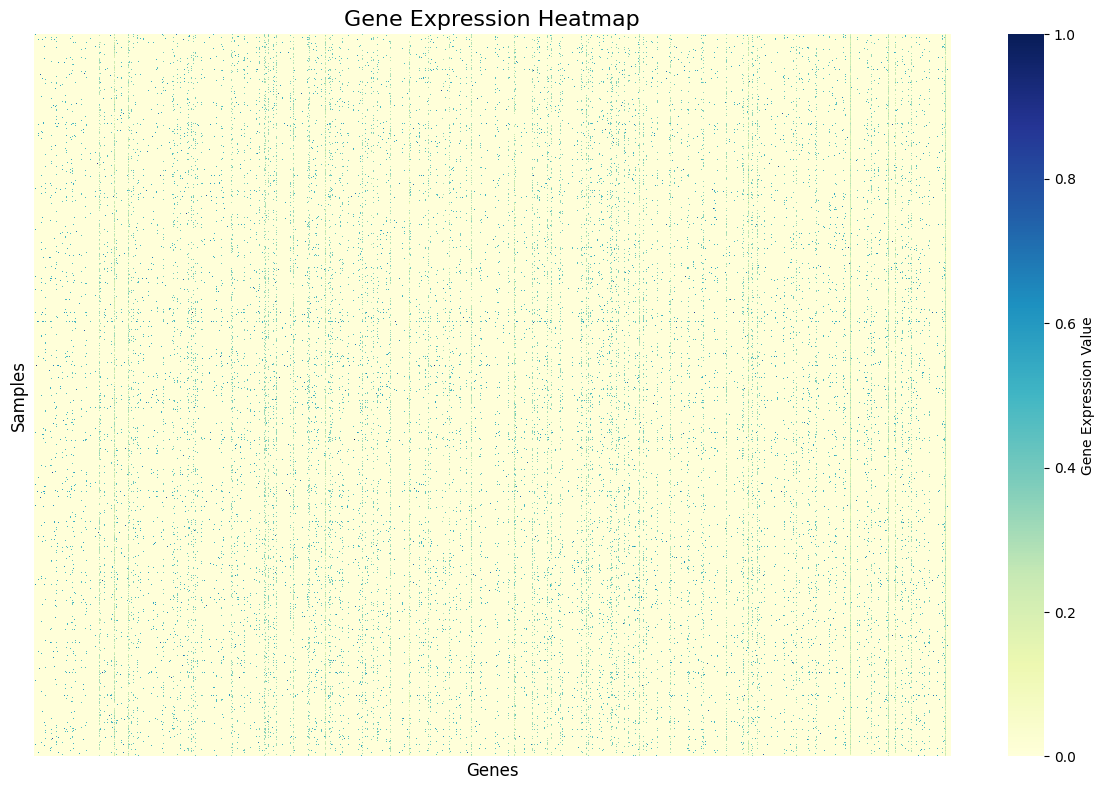

In [ ]:
heatmap_data = normalized_data.iloc[:, 1:]
heatmap_data = heatmap_data.sample(n=5000, axis=0)
heatmap_data = heatmap_data.iloc[:, :5000]

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Gene Expression Value'}
)

plt.title('Gene Expression Heatmap', fontsize=16)
plt.xlabel('Genes', fontsize=12)
plt.ylabel('Samples', fontsize=12)

plt.tight_layout()
plt.show()

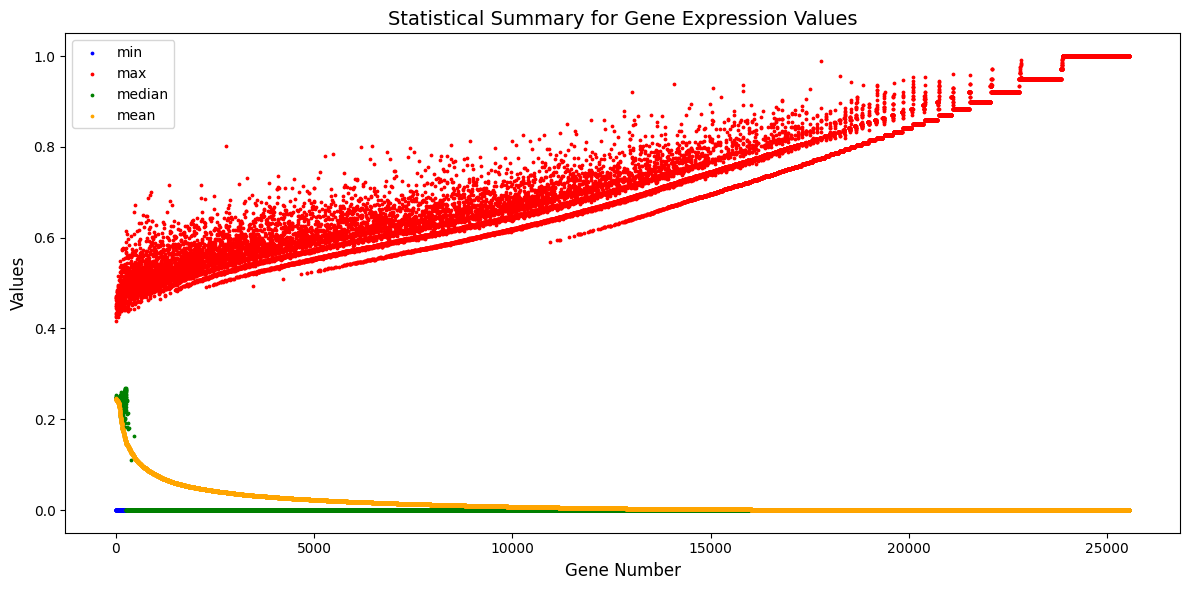

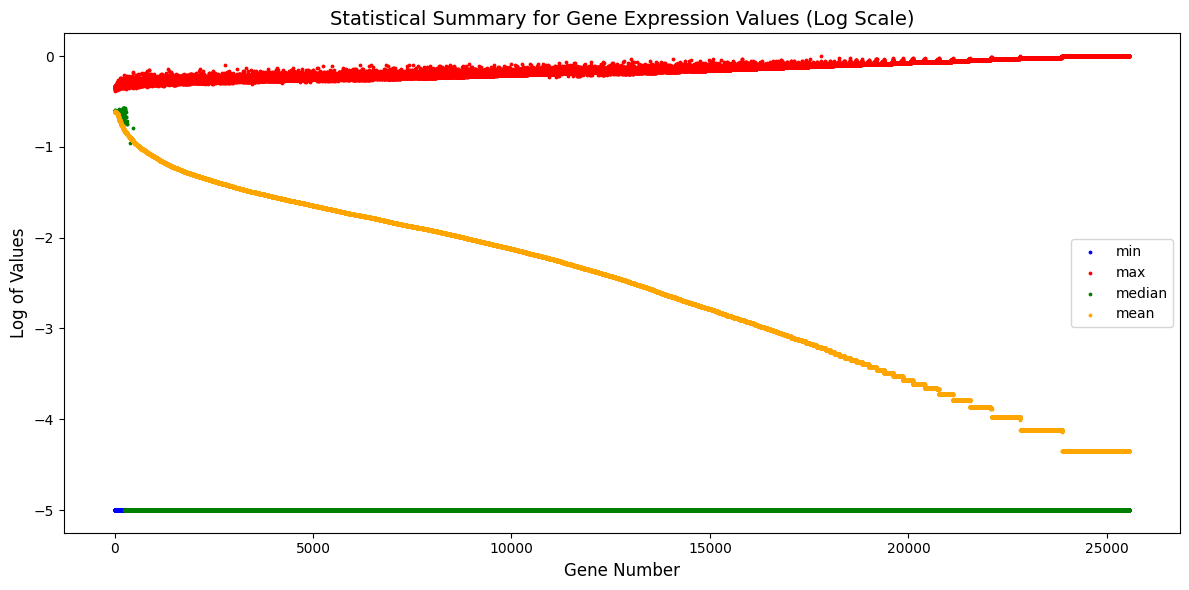

In [ ]:
gene_data = normalized_data.iloc[:, 1:]

gene_min = gene_data.min(axis=0)
gene_max = gene_data.max(axis=0)
gene_median = gene_data.median(axis=0)
gene_mean = gene_data.mean(axis=0)

gene_stats = pd.DataFrame({
    'min': gene_min,
    'max': gene_max,
    'median': gene_median,
    'mean': gene_mean
})

gene_stats = gene_stats.sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))
plt.scatter(range(len(gene_stats)), gene_stats['min'], label='min', s=3, color='blue')
plt.scatter(range(len(gene_stats)), gene_stats['max'], label='max', s=3, color='red')
plt.scatter(range(len(gene_stats)), gene_stats['median'], label='median', s=3, color='green')
plt.scatter(range(len(gene_stats)), gene_stats['mean'], label='mean', s=3, color='orange')
plt.title('Statistical Summary for Gene Expression Values', fontsize=14)
plt.xlabel('Gene Number', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['min'] + 1e-5), label='min', s=3, color='blue')
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['max'] + 1e-5), label='max', s=3, color='red')
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['median'] + 1e-5), label='median', s=3, color='green')
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['mean'] + 1e-5), label='mean', s=3, color='orange')
plt.title('Statistical Summary for Gene Expression Values (Log Scale)', fontsize=14)
plt.xlabel('Gene Number', fontsize=12)
plt.ylabel('Log of Values', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()